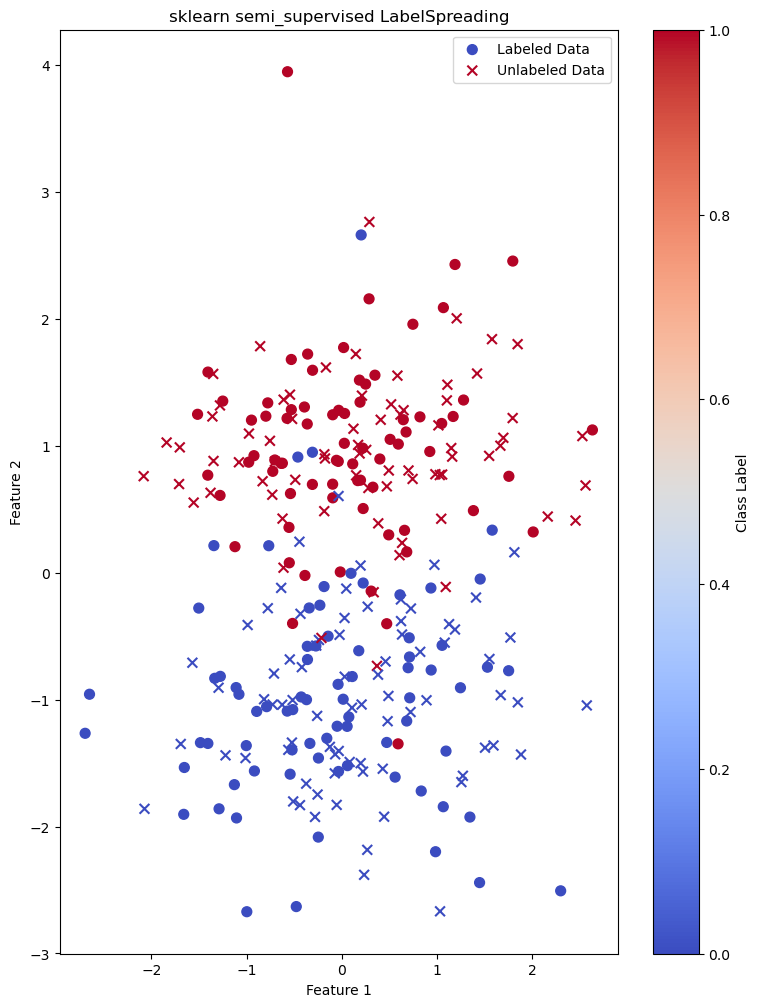

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.semi_supervised import LabelSpreading

# 生成一个示例数据集：2D特征，2个类别
X, y = make_classification(n_samples=300, n_features=5, n_informative=2, n_classes=2, random_state=42)

# 假设我们只有部分标签
y[150:] = -1  # 将后150个样本的标签设为-1，表示它们是未标记的数据

# 初始化LabelSpreading模型（转导学习的实现）
model = LabelSpreading(kernel='knn', n_neighbors=5)

# 训练模型
model.fit(X, y)

# 获取预测标签
y_pred = model.transduction_

# 可视化已标记和未标记的数据
plt.figure(figsize=(9, 12))  # 设置 3:4 的比例

# 已标记数据（标记为0或1的类别）
plt.scatter(X[y != -1, 0], X[y != -1, 1], c=y[y != -1], s=50, cmap='coolwarm', label='Labeled Data')

# 未标记数据（标签为-1的数据）
plt.scatter(X[y == -1, 0], X[y == -1, 1], c=y_pred[y == -1], s=50, marker='x', cmap='coolwarm', label='Unlabeled Data')

plt.title('sklearn semi_supervised LabelSpreading')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.colorbar(label='Class Label')
plt.show()

